#### 생선의 길이를 사용하여 무게를 예측

In [1]:
import numpy as np

In [2]:
fish_length = np.array(
    [8.4, 13.7, 15.0, 16.2, 17.4, 18.0, 18.7, 19.0, 19.6, 20.0, 
     21.0, 21.0, 21.0, 21.3, 22.0, 22.0, 22.0, 22.0, 22.0, 22.5, 
     22.5, 22.7, 23.0, 23.5, 24.0, 24.0, 24.6, 25.0, 25.6, 26.5, 
     27.3, 27.5, 27.5, 27.5, 28.0, 28.7, 30.0, 32.8, 34.5, 35.0, 
     36.5, 36.0, 37.0, 37.0, 39.0, 39.0, 39.0, 40.0, 40.0, 40.0, 
     40.0, 42.0, 43.0, 43.0, 43.5, 44.0]
     )
fish_weight = np.array(
    [5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0, 
     110.0, 115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0, 
     130.0, 150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0, 
     197.0, 218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0, 
     514.0, 556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0, 
     820.0, 850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0, 
     1000.0, 1000.0]
     )

#### 길이와 무게를 산포도로 표현

In [4]:
import matplotlib.pyplot as plt

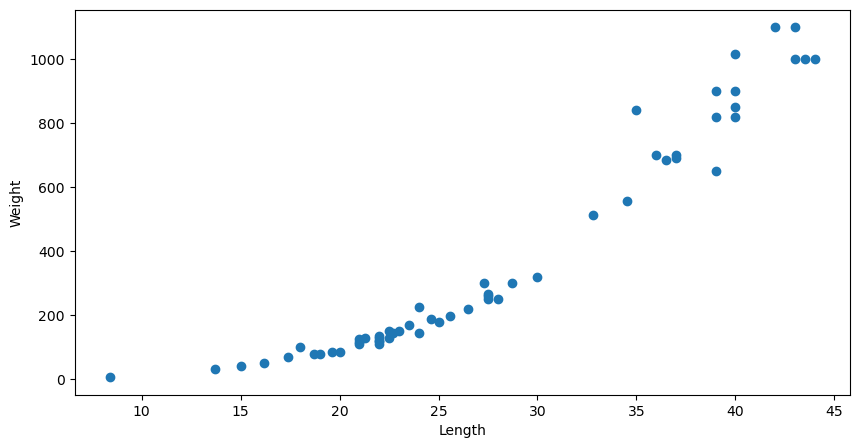

In [5]:
plt.figure(figsize=(10, 5))

plt.scatter(
    fish_length,
    fish_weight
)

plt.xlabel('Length')
plt.ylabel('Weight')

plt.show()

In [6]:
from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target = \
    train_test_split(
        fish_length,
        fish_weight,
        random_state=42,
        # stratify=fish_weight : regressor는 stratify를 사용하지 않음
    )

In [8]:
# 분리된 결과 확인
print(train_input.shape, test_input.shape)
print(train_target.shape, test_target.shape)

(42,) (14,)
(42,) (14,)


In [9]:
train_input

array([19.6, 22. , 18.7, 17.4, 36. , 25. , 40. , 39. , 43. , 22. , 20. ,
       22. , 24. , 27.5, 43. , 40. , 24. , 21. , 27.5, 40. , 32.8, 26.5,
       36.5, 13.7, 22.7, 15. , 37. , 35. , 28.7, 23.5, 39. , 21. , 23. ,
       22. , 44. , 22.5, 19. , 37. , 22. , 25.6, 42. , 34.5])

In [10]:
# 1열로 구성된 배열로 재구성
train_input = train_input.reshape(-1,1)

In [13]:
test_input = test_input.reshape(-1, 1)

In [14]:
print(train_input.shape, test_input.shape)

(42, 1) (14, 1)


### 회귀 모델 사용

In [15]:
from sklearn.neighbors import KNeighborsRegressor

In [16]:
knr = KNeighborsRegressor(n_neighbors=5)
knr.fit(train_input, train_target)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [19]:
print(knr.score(train_input, train_target))
print(knr.score(test_input, test_target))
# 과소적합 모델은 사용할 수 없다

0.9698823289099254
0.992809406101064


> 회귀모델은 분류모델과 같이 예측값과 정답값을 비교할 수 없음

### 결정계수 : 평균절댓값오차 (MAE Mean Absolute Error)

In [20]:
from sklearn.metrics import mean_absolute_error

In [21]:
# 테스트 세트에 대한 예측
pred = knr.predict(test_input)

In [22]:
pred

array([  60. ,   79.6,  248. ,  122. ,  136. ,  847. ,  311.4,  183.4,
        847. ,  113. , 1010. ,   60. ,  248. ,  248. ])

In [23]:
# 테스트 세트에 대한 평균절댓값오차를 구한다
mae = mean_absolute_error(
    test_target,
    pred
)
mae

19.157142857142862

### knn의 Hyper Parameter를 조절

In [25]:
# 이웃의 갯수를 3으로 설정
knr.n_neighbors = 3

# 모델을 다시 훈련시킨다
knr.fit(train_input, train_target)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [26]:
print("Train : ", knr.score(train_input, train_target))
print("Test : ", knr.score(test_input, test_target))

Train :  0.9804899950518966
Test :  0.9746459963987609


In [27]:
pred = knr.predict(test_input)
mae = mean_absolute_error(test_target, pred)
mae

35.42380952380951

#### 이웃의 갯수 조절로 확인

In [34]:
# x축의 범위 확인
print(fish_weight.min())
print(fish_length.max())

5.9
44.0


In [36]:
knr = KNeighborsRegressor()
# x좌표 5 ~ 45
x = np.arange(5, 45).reshape(-1, 1)
x.shape

(40, 1)

In [ ]:
# for i in [1, 3, 5, 10]:
#     knr.n_neighbors = i
#     knr.fit(train_input, train_target)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


k => 1
Train Score  0.9852830341215901
Test Score  0.991309195814175
----------------------------------------


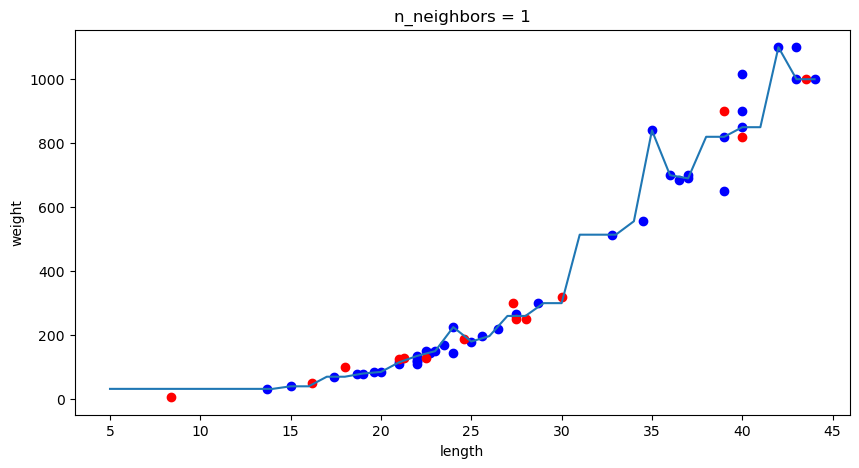

k => 3
Train Score  0.9804899950518966
Test Score  0.9746459963987609
----------------------------------------


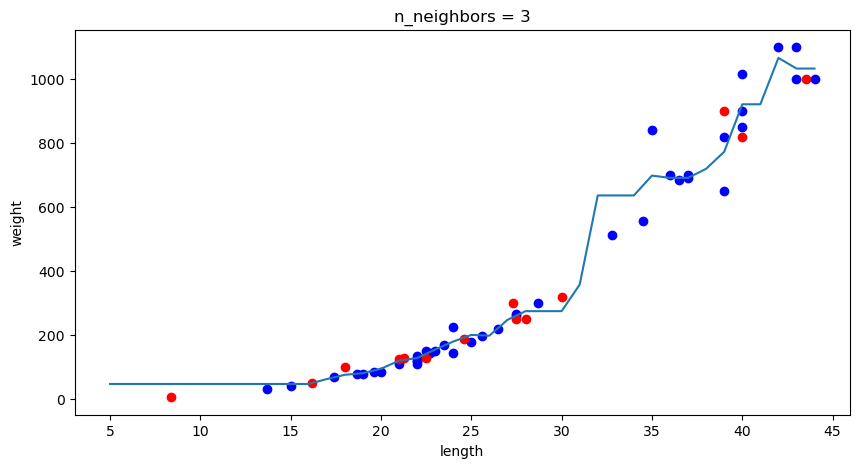

k => 5
Train Score  0.9698823289099254
Test Score  0.992809406101064
----------------------------------------


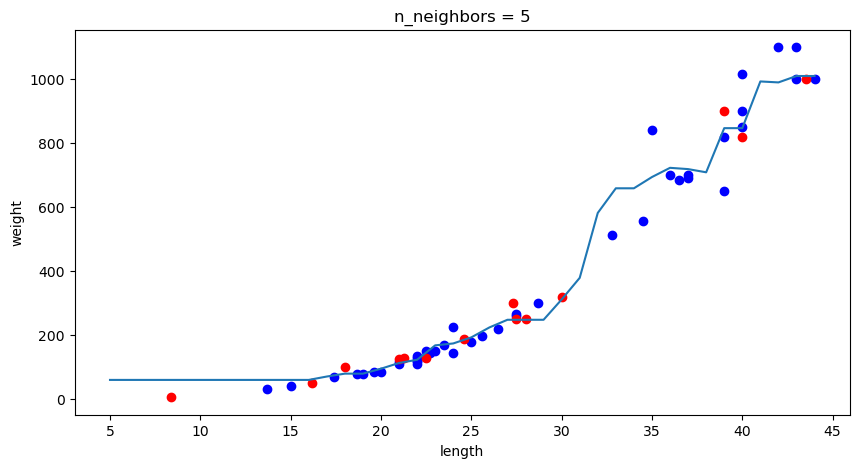

k => 10
Train Score  0.96164569026043
Test Score  0.9737908255822255
----------------------------------------


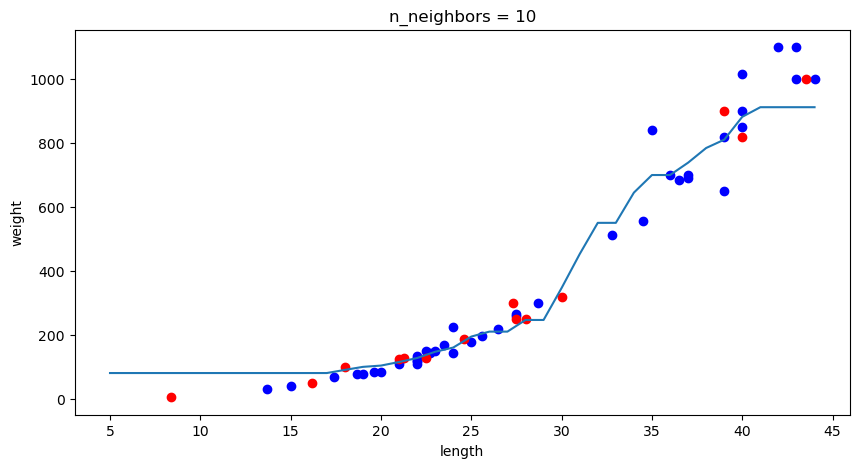

In [44]:
for i in [1, 3, 5, 10]:
    knr.n_neighbors = i
    knr.fit(train_input, train_target)
    print(f'k => {i}')
    print("Train Score ", knr.score(train_input, train_target))
    print("Test Score ", knr.score(test_input, test_target))
    print('-' * 40)

    # 지정한 범위 x에 대한 예측 구하기
    pred = knr.predict(x)

    # 훈련세트와 검증세트의 예측 결과 그래프 그리기
    plt.figure(figsize=(10, 5))

    plt.scatter(
        train_input, 
        train_target,
        c='blue'
    )

    plt.scatter(
        test_input,
        test_target,
        c='red'
    )

    plt.plot(x, pred)
    plt.title(f'n_neighbors = {i}')
    plt.xlabel('length')
    plt.ylabel('weight')

    plt.show()